# Modelo de Identificação de Fraudes


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime as dt

from scipy.stats import kstest, normaltest, anderson

from sklearn.preprocessing import PowerTransformer, MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree, metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids, NearMiss 
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.combine import SMOTEENN

from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score,
    precision_recall_curve,
)

import warnings
from src.config import DADOS_MASTERCARD

warnings.filterwarnings('ignore')
sns.set_theme(palette="bright")

In [6]:
# Importando a base

transacoes = pd.read_csv(DADOS_MASTERCARD)

In [4]:
# Verificar se todos os valores podem ser convertidos para inteiro (sem valores decimais)

if (transacoes['Time'] == transacoes['Time'].astype(int)).all():
    
    # Se todos os valores são inteiros, realizar a conversão
    
    transacoes['Time'] = transacoes['Time'].astype(int)
   
else:
    print("Nem todos os valores na coluna 'Time' podem ser convertidos para inteiro.")

### Vamos ajustar a escala de duas colunas para testar o resultado
- As colunas Time e Amount têm valores max muito alto. Destoa do restante do dataset.

In [6]:
# Verificando o resumo das colunas

transacoes.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**Podemos ajustar as colunas Time e Amount para que elas fiquem entre 0 e 1**
- Para isso, vamos dividir toda a coluna pelo valor máximo.

In [8]:
# Primeiro para a coluna Time

transacoes.Time = transacoes.Time / transacoes.Time.max()

# E então para a coluna Amount

transacoes.Amount = transacoes.Amount / transacoes.Amount.max()

<a id='modelo'></a>
### Criando um modelo de aprendizado de máquinas para identificar fraude
- Vamos criar um modelo para identificar fraude sem fazer nenhum tratamento nessa base

In [10]:
# Separando X e y

X = transacoes.drop('Class', axis=1)
y = transacoes.Class

**Separando em treino e teste**

In [12]:
# Separando em treino e teste

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42,stratify=y)

**Utilizando a árvore de decisão como fizemos anteriormente**

In [14]:
# Definindo o nosso classificador

clf = tree.DecisionTreeClassifier(random_state=42, max_depth=3)

In [15]:
# Fazendo o fit para os dados de treino

clf = clf.fit(X_train, y_train)

In [16]:
# Prevendo os valores

y_pred = clf.predict(X_test)

**Visualizando a matriz confusão**

In [18]:
confusion_matrix(y_test,y_pred)

array([[93793,    32],
       [   42,   120]], dtype=int64)

### Realizando o random undersampling

In [20]:
# Definindo o RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

In [21]:
# Definindo a nova amostra

X_res_RUS, y_res_RUS = rus.fit_resample(X_train, y_train)

**<font color='blue'>Com árvore de decisão**

In [23]:
# Fazendo o fit para os dados de treino já balanceados

clfTree_RUS = tree.DecisionTreeClassifier(random_state=42, max_depth=3)

clfTree_RUS = clf.fit(X_res_RUS, y_res_RUS)

In [24]:
# Fazendo a previsão para os dados de teste

y_predTree_RUS = clfTree_RUS.predict(X_test)
y_pred_probaTree_RUS = clfTree_RUS.predict_proba(X_test)[:,1]

In [25]:
# Visualizando a matriz confusão

confusion_matrix(y_test,y_predTree_RUS)

array([[90661,  3164],
       [   21,   141]], dtype=int64)

**<font color='blue'>Com Regressão Logística**

In [27]:
# Fazendo o fit

clfLog_RUS = LogisticRegression(random_state=0).fit(X_res_RUS, y_res_RUS)

In [28]:
# Fazendo a previsão

y_predLog_RUS = clfLog_RUS.predict(X_test)
y_pred_probaLog_RUS = clfLog_RUS.predict_proba(X_test)[:,1]

In [29]:
# Visualizando a matriz confusão

confusion_matrix(y_test,y_predLog_RUS)

array([[89868,  3957],
       [   15,   147]], dtype=int64)

**<font color='blue'>Com Support Vector Machine**

In [31]:
# Fazendo o fit

clfSVC_RUS = SVC(random_state=0, probability=True).fit(X_res_RUS, y_res_RUS)

In [32]:
# Fazendo a previsão

y_predSVC_RUS = clfSVC_RUS.predict(X_test)
y_pred_probaSVC_RUS = clfSVC_RUS.predict_proba(X_test)[:,1]

In [33]:
# Visualizando a matriz confusão

confusion_matrix(y_test,y_predSVC_RUS)

array([[92433,  1392],
       [   24,   138]], dtype=int64)

**<font color='blue'>Utilizando KNN**

In [35]:
# Fazendo o fit

clfKNN_RUS = KNeighborsClassifier(n_neighbors=3).fit(X_res_RUS, y_res_RUS)

In [36]:
# Fazendo a previsão

y_predKNN_RUS = clfKNN_RUS.predict(X_test)
y_pred_probaKNN_RUS = clfKNN_RUS.predict_proba(X_test)[:,1]

In [37]:
# Visualizando a matriz confusão

confusion_matrix(y_test,y_predKNN_RUS)

array([[91136,  2689],
       [   15,   147]], dtype=int64)

**<font color='blue'>Random Forest**

In [39]:
# Fazendo o fit

clfRFC_RUS = RandomForestClassifier(max_depth=2, random_state=0).fit(X_res_RUS, y_res_RUS)

In [40]:
# Fazendo a previsão

y_predRFC_RUS = clfRFC_RUS.predict(X_test)
y_pred_probaRFC_RUS = clfRFC_RUS.predict_proba(X_test)[:,1]

In [41]:
# Visualizando a matriz confusão

confusion_matrix(y_test,y_predRFC_RUS)

array([[93168,   657],
       [   25,   137]], dtype=int64)

### Comparando os modelos com recall e precisão

In [43]:
# Visualizando precisão e recall

print(precision_score(y_test,y_predTree_RUS))
print(recall_score(y_test,y_predTree_RUS))
print(precision_score(y_test,y_predLog_RUS))
print(recall_score(y_test,y_predLog_RUS))
print(precision_score(y_test,y_predSVC_RUS))
print(recall_score(y_test,y_predSVC_RUS))
print(precision_score(y_test,y_predKNN_RUS))
print(recall_score(y_test,y_predKNN_RUS))
print(precision_score(y_test,y_predRFC_RUS))
print(recall_score(y_test,y_predRFC_RUS))

0.04266263237518911
0.8703703703703703
0.035818713450292396
0.9074074074074074
0.09019607843137255
0.8518518518518519
0.05183356840620593
0.9074074074074074
0.172544080604534
0.845679012345679


In [44]:
# Gerando os parâmetros da curva precisão x recall para a base

precisionTree_RUS, recallTree_RUS, thresholdsTree_RUS = precision_recall_curve(y_test,y_pred_probaTree_RUS)
precisionLog_RUS, recallLog_RUS, thresholdsLog_RUS = precision_recall_curve(y_test,y_pred_probaLog_RUS)
precisionSVC_RUS, recallSVC_RUS, thresholdsSVC_RUS = precision_recall_curve(y_test,y_pred_probaSVC_RUS)
precisionKNN_RUS, recallKNN_RUS, thresholdsKNN_RUS = precision_recall_curve(y_test,y_pred_probaKNN_RUS)
precisionRFC_RUS, recallRFC_RUS, thresholdsRFC_RUS = precision_recall_curve(y_test,y_pred_probaRFC_RUS)

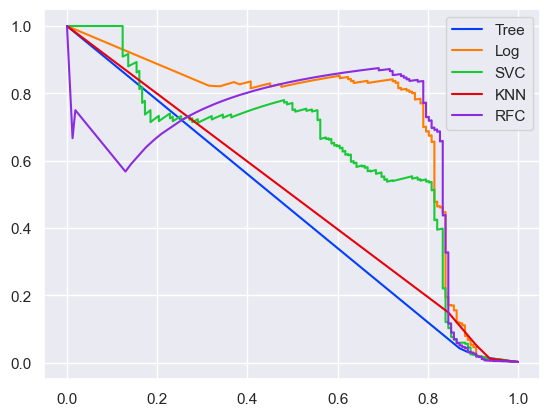

In [45]:
# Visualizando graficamente

import matplotlib.pyplot as plt

# Traçando a curva ROC

fig, ax = plt.subplots()

ax.plot(recallTree_RUS, precisionTree_RUS, label='Tree')
ax.plot(recallLog_RUS, precisionLog_RUS, label='Log')
ax.plot(recallSVC_RUS, precisionSVC_RUS, label='SVC')
ax.plot(recallKNN_RUS, precisionKNN_RUS, label='KNN')
ax.plot(recallRFC_RUS, precisionRFC_RUS, label='RFC')

ax.legend()
plt.show()

In [46]:
# Avaliando a área abaixo da curva de cada um dos casos (Após a mundança em Times e Amount)

print(metrics.auc(recallTree_RUS, precisionTree_RUS))
print(metrics.auc(recallLog_RUS, precisionLog_RUS))
print(metrics.auc(recallSVC_RUS, precisionSVC_RUS))
print(metrics.auc(recallKNN_RUS, precisionKNN_RUS))
print(metrics.auc(recallRFC_RUS, precisionRFC_RUS))

0.45591395591445655
0.7177264329605954
0.6152583149080748
0.49345655068764066
0.6504912358563952
